# Inference capacity, batching, and autoscaling

CPU companion; no accelerator is required. TPU execution not validated.

- Measure completed inference after warming each batch shape
- Report batch latency and example throughput with correct units
- Implement and independently check a serial queue timeline
- Distinguish utilization, batch-collection delay and hypothetical replica planning from measured service evidence

A model call looks fast in isolation, yet users may wait when requests arrive together. We will measure actual completed inference at several batch sizes, then use those observations in a clearly labeled queue simulation. The aim is to connect milliseconds per batch, examples per second and response latency without confusing a local benchmark with a deployed service.

## The idea

A service can spend time waiting for a worker, collecting a batch and executing inference. Batching amortizes some fixed work but can add waiting and memory. Capacity planning needs a declared workload, timed boundary and arrival process. Our local CPU timings measure only resident-input inference; the queue experiment adds a hypothetical arrival schedule, not an observed network workload.

## Choose the clock boundary first

JAX dispatch may return before numerical work has completed. The timer calls block_until_ready inside the measured interval. Inputs and weights are already resident; preprocessing, device placement, request decoding and response encoding are excluded. The first call for each shape can include compilation and is recorded separately from $40$ warm calls. A p95 from $40$ samples is a small descriptive statistic, not a reliable production tail estimate. Timings change across hosts and repeated runs; correctness checks must not assert a fixed speedup.

## Keep request units and example units separate

Let a batch of $B$ examples take $t_B$ milliseconds. A serial worker completing full batches has a compute-throughput proxy $1000B/t_B$ examples per second. The batch still takes $t_B$ milliseconds; dividing by $B$ describes amortized cost per example, not the response time experienced by one example in that batch. Partial batches, memory pressure, shape recompilation and preprocessing can change both numbers.

$$
q_B=\frac{1000B}{t_B}\quad\text{examples/second}
$$

## Trace a queue before using a rate formula

For one first-come-first-served worker, a request starts at the later of its arrival and the previous finish. With arrivals at $0,1,4$ milliseconds and service duration $2$ milliseconds, starts are $0,2,4$, finishes are $2,4,6$, and response times are $2,3,2$. The second request waits one millisecond because the worker is busy. This independent hand timeline checks our simulation before we feed it measured service durations.

$$
s_i=\max(a_i,f_{i-1}),\qquad f_i=s_i+t,\qquad r_i=f_i-a_i
$$

## A utilization estimate is not a latency guarantee

If arrival rate is $\lambda$ requests per second and each request consumes $t$ milliseconds on one serial worker, the utilization proxy is $\rho=\lambda t/1000$. Sustained offered work above capacity makes backlog grow in this unlimited-queue model. Even below capacity, bursts and service-time variation can cause long waits. Our stable arrivals are spaced $1.5t$ apart, so no queue forms. Overloaded arrivals are $0.6t$ apart; waiting grows by $0.4t$ per request and the sixtieth response takes $24.6t$. These are simulated consequences of declared inputs, not measured user latencies.

## Batch collection trades waiting for throughput

With regularly spaced arrivals separated by $\delta$, filling a batch of $B$ from empty makes its first example wait $(B-1)\delta$ before execution; the average collection wait is $(B-1)\delta/2$ if all positions are equally represented. A timeout permits partial batches and limits intentional collection delay, but a busy worker can still add queueing. A production experiment should replay realistic arrivals, batch sizes and sequence lengths, record queue, collection and execution times separately, and compare tail latency against an explicit service-level objective. This lesson measures batch computation and simulates a batch-one queue; it does not claim a dynamic batching server ran.

## Plan replicas with headroom, then test the plan

For a measured effective capacity $q$ requests per second per replica and target utilization $u$, a first estimate is $R=\lceil\lambda/(u q)\rceil$. This assumes compatible units, balanced routing and an actual capacity measurement for the workload. Autoscaling also has observation windows, startup time, warming and cooldown; it cannot erase a burst that arrives before new capacity is ready. Keep the formula labeled as a planning assumption until a load test includes the real request boundary, concurrency limits, failures and startup behavior.

## 1. Define and check the inference workload

Create a fresh main.py. This fixed dense-network fixture measures an inference boundary; its random weights are not presented as a pretrained or accurate model.

In [1]:
import math
import time
import numpy as np
import jax
import jax.numpy as jnp
rng=np.random.default_rng(82)
W1=jnp.asarray(rng.normal(0,.1,(64,32)).astype(np.float32))
W2=jnp.asarray(rng.normal(0,.1,(32,8)).astype(np.float32))
@jax.jit
def infer(inputs):
    return jnp.tanh(inputs@W1)@W2
def measure(batch_size,repeats=40):
    host=rng.normal(size=(batch_size,64)).astype(np.float32)
    device=jnp.asarray(host)
    began=time.perf_counter()
    first=infer(device).block_until_ready()
    first_ms=(time.perf_counter()-began)*1000
    expected=np.tanh(host@np.asarray(W1))@np.asarray(W2)
    np.testing.assert_allclose(first,expected,rtol=2e-5,atol=2e-6)
    samples=[]
    for _ in range(repeats):
        began=time.perf_counter()
        infer(device).block_until_ready()
        samples.append((time.perf_counter()-began)*1000)
    p50=float(np.percentile(samples,50))
    return {'batch':batch_size,'first_call_ms':first_ms,'samples_ms':samples,
            'p50_ms':p50,'p95_ms':float(np.percentile(samples,95)),
            'steady_examples_per_second':1000*batch_size/p50}

The timer includes dispatch and completion for already resident inputs. JSON, networking, queueing and host-to-device placement are outside this boundary.

## 2. Measure each batch shape separately

Append three batch shapes and print all timing boundaries. Each shape has its own first call and warmed sample distribution.

In [2]:
measurements=[measure(batch) for batch in (1,8,32)]
for report in measurements:
    assert len(report['samples_ms'])==40
    assert all(value>0 and np.isfinite(value) for value in report['samples_ms'])
    print({key:value for key,value in report.items() if key!='samples_ms'})
service_ms=measurements[0]['p50_ms']

{'batch': 1, 'first_call_ms': 33.39570784009993, 'p50_ms': 0.009271083399653435, 'p95_ms': 0.011856493074446913, 'steady_examples_per_second': 107862.25912252945}
{'batch': 8, 'first_call_ms': 18.46204185858369, 'p50_ms': 0.009562470950186253, 'p95_ms': 0.023283762857317918, 'steady_examples_per_second': 836603.848699188}
{'batch': 32, 'first_call_ms': 17.68462499603629, 'p50_ms': 0.015250523574650288, 'p95_ms': 0.027177098672837015, 'steady_examples_per_second': 2098288.6156899566}


Do not assume a larger batch is faster per request. Examples per second and milliseconds per batch answer different questions.

## 3. Model a queue with an independent hand-check

Append the FCFS simulator and two hypothetical arrival schedules. Times are milliseconds throughout the simulation.

In [3]:
def simulate_queue(arrival_ms,service_ms):
    arrivals=np.asarray(arrival_ms,dtype=float)
    if arrivals.ndim!=1 or np.any(~np.isfinite(arrivals)) or np.any(np.diff(arrivals)<0):
        raise ValueError('arrivals must be a finite ordered vector')
    if not np.isfinite(service_ms) or service_ms<=0:
        raise ValueError('service duration must be positive milliseconds')
    ready=0.
    starts=[];finishes=[]
    for arrival in arrivals:
        start=max(float(arrival),ready)
        ready=start+service_ms
        starts.append(start);finishes.append(ready)
    return np.array(starts),np.array(finishes),np.array(finishes)-arrivals
hand_start,hand_finish,hand_latency=simulate_queue([0.,1.,4.],2.)
np.testing.assert_allclose(hand_start,[0.,2.,4.])
np.testing.assert_allclose(hand_finish,[2.,4.,6.])
np.testing.assert_allclose(hand_latency,[2.,3.,2.])
request_index=np.arange(60)
stable_arrivals=request_index*1.5*service_ms
overloaded_arrivals=request_index*.6*service_ms
_,_,stable_latency=simulate_queue(stable_arrivals,service_ms)
_,_,overloaded_latency=simulate_queue(overloaded_arrivals,service_ms)
assert np.allclose(stable_latency,service_ms)
assert np.isclose(overloaded_latency[-1],24.6*service_ms)
print('measured batch-one service proxy (ms):',service_ms)
print('simulated last stable/overloaded response (ms):',stable_latency[-1],overloaded_latency[-1])

measured batch-one service proxy (ms): 0.009271083399653435
simulated last stable/overloaded response (ms): 0.009271083399653435 0.2280686516314745


This simulator assumes one serial worker and a constant service duration derived from the measured median. It is not a load test, an HTTP server or an autoscaler.

## Run the example

In [4]:
import math
import time
import numpy as np
import jax
import jax.numpy as jnp
rng=np.random.default_rng(82)
W1=jnp.asarray(rng.normal(0,.1,(64,32)).astype(np.float32))
W2=jnp.asarray(rng.normal(0,.1,(32,8)).astype(np.float32))
@jax.jit
def infer(inputs):
    return jnp.tanh(inputs@W1)@W2
def measure(batch_size,repeats=40):
    host=rng.normal(size=(batch_size,64)).astype(np.float32)
    device=jnp.asarray(host)
    began=time.perf_counter()
    first=infer(device).block_until_ready()
    first_ms=(time.perf_counter()-began)*1000
    expected=np.tanh(host@np.asarray(W1))@np.asarray(W2)
    np.testing.assert_allclose(first,expected,rtol=2e-5,atol=2e-6)
    samples=[]
    for _ in range(repeats):
        began=time.perf_counter()
        infer(device).block_until_ready()
        samples.append((time.perf_counter()-began)*1000)
    p50=float(np.percentile(samples,50))
    return {'batch':batch_size,'first_call_ms':first_ms,'samples_ms':samples,
            'p50_ms':p50,'p95_ms':float(np.percentile(samples,95)),
            'steady_examples_per_second':1000*batch_size/p50}

measurements=[measure(batch) for batch in (1,8,32)]
for report in measurements:
    assert len(report['samples_ms'])==40
    assert all(value>0 and np.isfinite(value) for value in report['samples_ms'])
    print({key:value for key,value in report.items() if key!='samples_ms'})
service_ms=measurements[0]['p50_ms']

def simulate_queue(arrival_ms,service_ms):
    arrivals=np.asarray(arrival_ms,dtype=float)
    if arrivals.ndim!=1 or np.any(~np.isfinite(arrivals)) or np.any(np.diff(arrivals)<0):
        raise ValueError('arrivals must be a finite ordered vector')
    if not np.isfinite(service_ms) or service_ms<=0:
        raise ValueError('service duration must be positive milliseconds')
    ready=0.
    starts=[];finishes=[]
    for arrival in arrivals:
        start=max(float(arrival),ready)
        ready=start+service_ms
        starts.append(start);finishes.append(ready)
    return np.array(starts),np.array(finishes),np.array(finishes)-arrivals
hand_start,hand_finish,hand_latency=simulate_queue([0.,1.,4.],2.)
np.testing.assert_allclose(hand_start,[0.,2.,4.])
np.testing.assert_allclose(hand_finish,[2.,4.,6.])
np.testing.assert_allclose(hand_latency,[2.,3.,2.])
request_index=np.arange(60)
stable_arrivals=request_index*1.5*service_ms
overloaded_arrivals=request_index*.6*service_ms
_,_,stable_latency=simulate_queue(stable_arrivals,service_ms)
_,_,overloaded_latency=simulate_queue(overloaded_arrivals,service_ms)
assert np.allclose(stable_latency,service_ms)
assert np.isclose(overloaded_latency[-1],24.6*service_ms)
print('measured batch-one service proxy (ms):',service_ms)
print('simulated last stable/overloaded response (ms):',stable_latency[-1],overloaded_latency[-1])

{'batch': 1, 'first_call_ms': 18.993833102285862, 'p50_ms': 0.026145484298467636, 'p95_ms': 0.05735444137826561, 'steady_examples_per_second': 38247.52253904928}
{'batch': 8, 'first_call_ms': 18.917000154033303, 'p50_ms': 0.026145949959754944, 'p95_ms': 0.074677518568933, 'steady_examples_per_second': 305974.7307829308}
{'batch': 32, 'first_call_ms': 19.26416694186628, 'p50_ms': 0.014771008864045143, 'p95_ms': 0.02897081431001424, 'steady_examples_per_second': 2166405.849088129}
measured batch-one service proxy (ms): 0.026145484298467636
simulated last stable/overloaded response (ms): 0.026145484298467636 0.6431789137423038


Expected: The program prints first-call, warm p50/p95 and examples-per-second measurements for each batch size. Absolute timings are host-dependent. The independent queue example yields response times of 2, 3 and 2 milliseconds.

## Measured batch computation and a separately simulated queue

Predict: Can a queue grow even when the duration of each individual model call is unchanged?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data={"kind":"panels","panels":[{"kind":"bar","x":[0,1,2],"labels":["batch 1","batch 8","batch 32"],"xlabel":"resident-input batch shape","ylabel":"measured CPU milliseconds per batch","series":[{"label":"warm p50","y":[r["p50_ms"] for r in measurements]},{"label":"warm p95","y":[r["p95_ms"] for r in measurements]}]},{"kind":"line","x":request_index.tolist(),"xlabel":"request index (simulation)","ylabel":"simulated response / measured service","series":[{"label":"spaced arrivals","y":(stable_latency/service_ms).tolist()},{"label":"overloaded arrivals","y":(overloaded_latency/service_ms).tolist()}]}]}

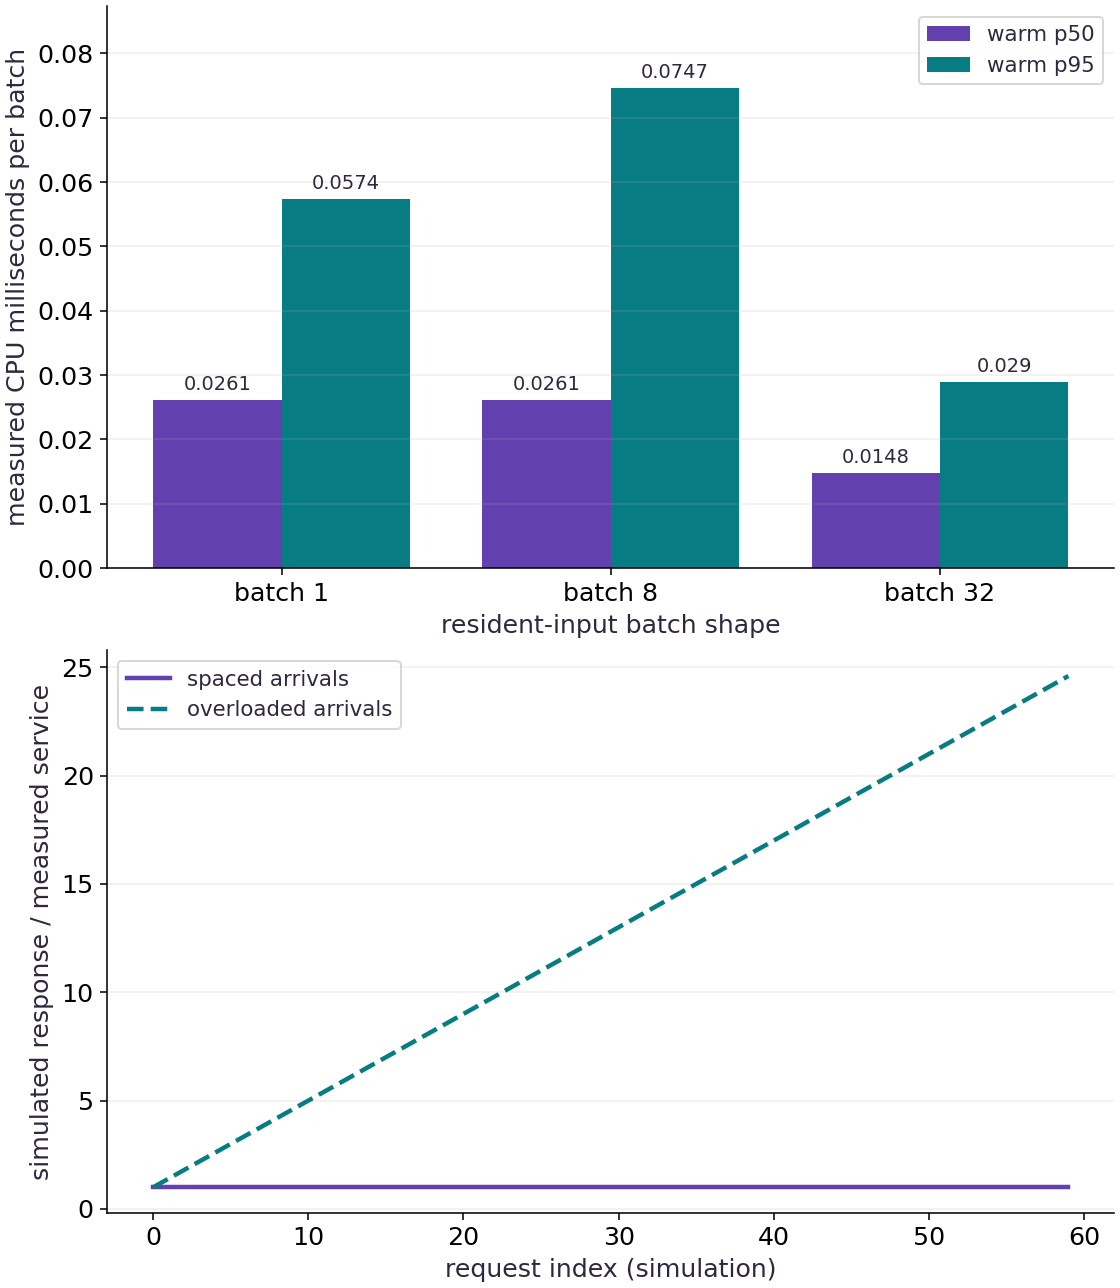

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The upper panel shows measured CPU warm p50 and p95 milliseconds per batch for batch sizes $1,8,32$. Each timing waits for completion; inputs are already resident. These are sample percentiles, not confidence bounds or a speedup guarantee. The lower panel uses request index on the horizontal axis and simulated response time divided by the measured batch-one median on the vertical axis. Stable arrivals stay at $1$; overloaded arrivals rise from $1$ to $24.6$.

### Connect it to the computation

The lower panel’s growth comes entirely from the chosen arrival schedule and serial queue recurrence. The service duration stays fixed in the simulation. Normalizing by the measured service duration makes the buildup visible without freezing host-dependent milliseconds into the prose. Real requests can add networking, preprocessing, variable service times and batch collection; those costs are not inferred from this graph.

## Compute a replica estimate with explicit units

Predict: At 300 requests per second, 200 requests per second of effective capacity per replica, and 70% target utilization, how many replicas does the planning formula suggest?

In [7]:
arrival_per_s=300.;capacity_per_s=200.;target_utilization=.7
replicas=math.ceil(arrival_per_s/(target_utilization*capacity_per_s))
assert replicas==3
print("hypothetical planned replicas:",replicas)

hypothetical planned replicas: 3


Expected: The formula suggests three replicas under the stated assumptions.

This is arithmetic on hypothetical effective capacities, not an executed autoscaling test.

## Estimate batch-collection delay

Predict: For eight requests arriving two milliseconds apart, how long do the earliest and average request wait for a full batch before computation?

In [8]:
batch=8;spacing_ms=2.
collection_wait=(batch-1-np.arange(batch))*spacing_ms
assert collection_wait[0]==14.
assert collection_wait.mean()==7.

Expected: The first waits fourteen milliseconds; mean collection delay is seven milliseconds.

A throughput improvement can be overwhelmed by waiting for a batch at low arrival rates.

## Your exercise

Simulate a burst of four requests arriving at time zero with a two-millisecond serial service duration. Derive all finish times and response times before executing.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
_,burst_finish,burst_latency=simulate_queue([0.,0.,0.,0.],2.)
np.testing.assert_allclose(burst_finish,[2.,4.,6.,8.])
np.testing.assert_allclose(burst_latency,[2.,4.,6.,8.])

## Expose burst sensitivity · Transfer / diagnosis

Compare five requests spaced three milliseconds apart with five simultaneous requests. Use two-millisecond service and compare maximum response latency.

Hint: The worker is idle between spaced requests but never idle during the burst.

In [11]:
# Write your attempt here.

## Reference reasoning

An average arrival rate alone does not describe a burst or tail latency.

In [12]:
_,_,smooth=simulate_queue(np.arange(5)*3.,2.)
_,_,burst=simulate_queue(np.zeros(5),2.)
assert smooth.max()==2. and burst.max()==10.

## Reject a broken timeline · Transfer / diagnosis

Pass an out-of-order arrival vector and a zero service duration. Confirm both are rejected instead of returning a plausible chart.

Hint: Public simulation inputs need finite, ordered values and positive service time.

In [13]:
# Write your attempt here.

## Reference reasoning

Validating assumptions prevents a simulation from silently supporting a false capacity story.

In [14]:
for arrivals,duration in [([2.,1.],2.),([0.,1.],0.)]:
    try:
        simulate_queue(arrivals,duration)
    except ValueError:
        pass
    else:
        raise AssertionError("invalid timeline was accepted")

## Checkpoint

A batch of eight finishes in four milliseconds. Which statement follows for a fully occupied serial worker?

1. Every example experiences half a millisecond of response latency
2. The compute-throughput proxy is two thousand examples per second, while batch execution still takes four milliseconds
3. The service can guarantee the same throughput for every arrival pattern

## Diagnose

If timings look impossibly small, check that completion is inside the timer. If a larger batch improves examples per second but misses a latency target, inspect collection and queue delay before choosing replicas. If a capacity calculation differs by a thousand, label milliseconds versus seconds at every conversion.

## Evidence

Warm timing samples, latency/throughput units, independent queue timeline and labeled simulation/replica assumptions. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- Measure completion and declare the boundary.
- Batch throughput, amortized cost and individual response time are different quantities.
- A queue simulation and replica formula guide experiments; neither replaces a real service load test.

## Primary references

- [JAX benchmarking guidance](https://docs.jax.dev/en/latest/benchmarking.html)
- [JAX asynchronous dispatch](https://docs.jax.dev/en/latest/async_dispatch.html)